# CareerCopilot AI

## Personalized Career Intelligence & Skill Gap Analysis Platform

CareerCopilot AI is a data-driven career recommendation platform that analyzes real-world job postings to identify in-demand skills, hiring trends, and career opportunities.

### Objectives
- Analyze job market demand
- Identify top technical and non-technical skills
- Perform skill gap analysis
- Generate career readiness scores
- Provide personalized learning recommendations

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Power BI

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import os

print(os.getcwd())

C:\Users\MY DELL\Desktop\Career copilot_AI\notebooks


In [4]:
import os

os.listdir("..")


['.ipynb_checkpoints',
 'job_postings.csv',
 'job_skills.csv',
 'job_summary.csv',
 'notebooks']

In [5]:
job_postings = pd.read_csv("../job_postings.csv")
job_skills = pd.read_csv("../job_skills.csv")
job_summary = pd.read_csv("../job_summary.csv")

In [6]:
print("Job Postings:", job_postings.shape)
print("Job Skills:", job_skills.shape)
print("Job Summary:", job_summary.shape)

Job Postings: (12217, 15)
Job Skills: (12217, 2)
Job Summary: (12217, 2)


In [7]:
job_postings.head()

,job_link,last_processed_time,last_status,got_summary,got_ner,is_being_worked,job_title,company,job_location,first_seen,search_city,search_country,search_position,job_level,job_type
0,https://www.linkedin.com/jobs/view/senior-mach...,2024-01-21 08:08:48.031964+00,Finished NER,t,t,f,Senior Machine Learning Engineer,Jobs for Humanity,"New Haven, CT",2024-01-14,East Haven,United States,Agricultural-Research Engineer,Mid senior,Onsite
1,https://www.linkedin.com/jobs/view/principal-s...,2024-01-20 04:02:12.331406+00,Finished NER,t,t,f,"Principal Software Engineer, ML Accelerators",Aurora,"San Francisco, CA",2024-01-14,El Cerrito,United States,Set-Key Driver,Mid senior,Onsite
2,https://www.linkedin.com/jobs/view/senior-etl-...,2024-01-21 08:08:31.941595+00,Finished NER,t,t,f,Senior ETL Data Warehouse Specialist,Adame Services LLC,"New York, NY",2024-01-14,Middletown,United States,Technical Support Specialist,Associate,Onsite
3,https://www.linkedin.com/jobs/view/senior-data...,2024-01-20 15:30:55.796572+00,Finished NER,t,t,f,Senior Data Warehouse Developer / Architect,Morph Enterprise,"Harrisburg, PA",2024-01-12,Lebanon,United States,Architect,Mid senior,Onsite
4,https://www.linkedin.com/jobs/view/lead-data-e...,2024-01-21 08:08:58.312124+00,Finished NER,t,t,f,Lead Data Engineer,Dice,"Plano, TX",2024-01-14,McKinney,United States,Maintenance Data Analyst,Mid senior,Onsite


In [8]:
job_skills.head()

,job_link,job_skills
0,https://www.linkedin.com/jobs/view/senior-mach...,"Machine Learning, Programming, Python, Scala, ..."
1,https://www.linkedin.com/jobs/view/principal-s...,"C++, Python, PyTorch, TensorFlow, MXNet, CUDA,..."
2,https://www.linkedin.com/jobs/view/senior-etl-...,"ETL, Data Integration, Data Transformation, Da..."
3,https://www.linkedin.com/jobs/view/senior-data...,"Data Lakes, Data Bricks, Azure Data Factory Pi..."
4,https://www.linkedin.com/jobs/view/lead-data-e...,"Java, Scala, Python, RDBMS, NoSQL, Redshift, S..."


In [9]:
job_postings.columns

Index(['job_link', 'last_processed_time', 'last_status', 'got_summary',
       'got_ner', 'is_being_worked', 'job_title', 'company', 'job_location',
       'first_seen', 'search_city', 'search_country', 'search_position',
       'job_level', 'job_type'],
      dtype='object')

## Finding most in demand skills

In [12]:
all_skills = (
    job_skills["job_skills"]
    .dropna()
    .str.split(", ")
    .explode()
)

top_skills = all_skills.value_counts().head(20)

top_skills

job_skills
Python                4801
SQL                   4606
Communication         2498
Data Analysis         2181
Machine Learning      1966
AWS                   1740
Tableau               1685
Data Visualization    1562
R                     1542
Java                  1414
Spark                 1392
Data Science          1285
Data Engineering      1262
Teamwork              1218
Project Management    1213
Data Analytics        1115
Problem Solving       1093
Hadoop                1074
Collaboration         1072
Data analysis         1072
Name: count, dtype: int64

## Skill Demand Analysis

This analysis identifies the most frequently requested skills across thousands of job postings.

Understanding market demand helps students prioritize the skills that provide the highest employability and career growth opportunities.

The results will be used to:
- Build the Skill Gap Analyzer
- Generate Career Readiness Scores
- Recommend personalized learning paths

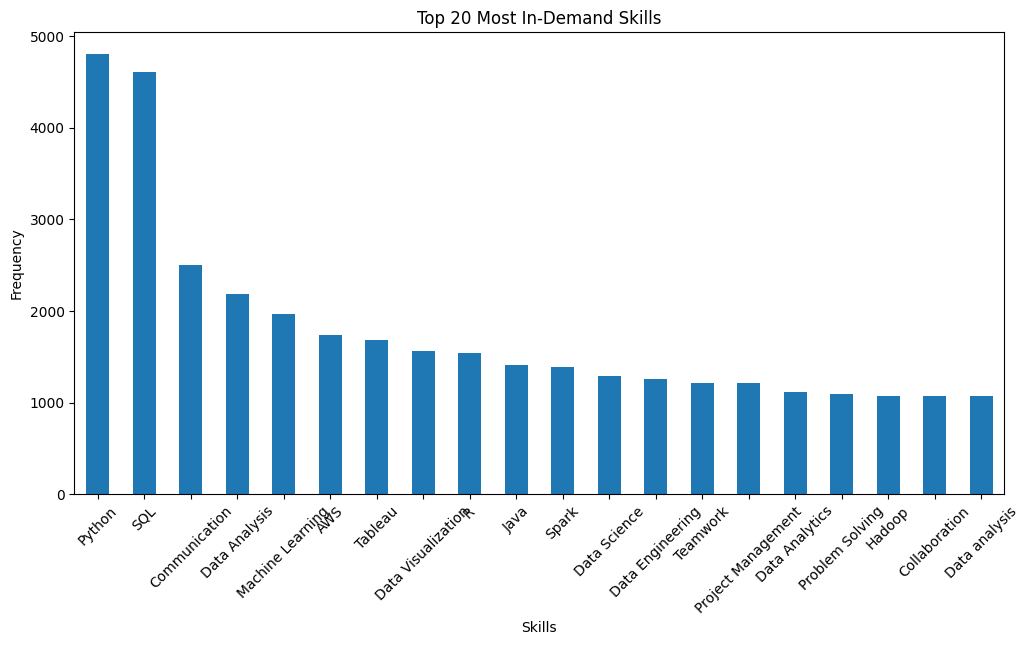

In [14]:
top_skills.plot(kind="bar", figsize=(12,6))

plt.title("Top 20 Most In-Demand Skills")
plt.xlabel("Skills")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

## Key Insights

### Technical Skills
- Python is the most demanded technical skill.
- SQL is the second most requested skill.
- Machine Learning remains highly relevant across job postings.
- AWS and Tableau are frequently requested in data-focused roles.

### Business Skills
- Communication appears among the most important skills, highlighting the need for strong interpersonal abilities.
- Data Analysis and Data Visualization are core competencies for analytics roles.

### Career Implications
Students targeting Data Analyst roles should prioritize:

1. Python
2. SQL
3. Data Analysis
4. Data Visualization
5. Tableau / Power BI

These skills consistently appear across a large percentage of job postings.

# SKILL GAP ANALYZER

In [15]:
top_10_skills = list(top_skills.head(10).index)

print(top_10_skills)

['Python', 'SQL', 'Communication', 'Data Analysis', 'Machine Learning', 'AWS', 'Tableau', 'Data Visualization', 'R', 'Java']


In [16]:
user_skills = ["Python", "Excel"]
missing_skills = []
for skill in top_10_skills:
    if skill not in user_skills:
        missing_skills.append(skill)

print("Your Skills:", user_skills)
print("Missing Skills:", missing_skills)

Your Skills: ['Python', 'Excel']
Missing Skills: ['SQL', 'Communication', 'Data Analysis', 'Machine Learning', 'AWS', 'Tableau', 'Data Visualization', 'R', 'Java']


## Skill Gap Analysis

The Skill Gap Analyzer compares a user's current skills against the most demanded skills identified from the job market.

### User Skills
- Python
- Excel

### Goal
Measure how closely the user's skills align with current industry requirements and identify areas for improvement.

In [19]:
matched_skills = []

for skill in top_10_skills:
    if skill in user_skills:
        matched_skills.append(skill)

readiness_score = (len(matched_skills) / len(top_10_skills)) * 100

print("Matched Skills:", matched_skills)
print(f"Readiness Score: {readiness_score:.2f}%")

Matched Skills: ['Python']
Readiness Score: 10.00%


## Results Interpretation

### Current Readiness Score
10%

### Missing Skills
- SQL
- Data Analysis
- Data Visualization
- Tableau
- AWS
- Machine Learning

### Recommendation
To improve employability for Data Analyst and Business Intelligence roles, focus on learning:

1. SQL
2. Power BI
3. Tableau
4. Data Visualization
5. Advanced Excel

Acquiring these skills would significantly increase market readiness and internship competitiveness.

# Career Roadmap Generator

Based on current market demand and identified skill gaps, CareerCopilot AI generates a personalized learning roadmap to improve career readiness.

In [20]:
roadmap = {
    1: "SQL",
    2: "Power BI",
    3: "Data Visualization",
    4: "Tableau",
    5: "Projects & Portfolio",
    6: "Interview Preparation"
}

for month, skill in roadmap.items():
    print(f"Month {month}: {skill}")

Month 1: SQL
Month 2: Power BI
Month 3: Data Visualization
Month 4: Tableau
Month 5: Projects & Portfolio
Month 6: Interview Preparation


## Personalized Learning Roadmap

### Month 1
Learn SQL fundamentals and database querying.

### Month 2
Develop Power BI dashboarding skills and KPI reporting.

### Month 3
Focus on data visualization principles and storytelling.

### Month 4
Learn Tableau and advanced dashboard design.

### Month 5
Build portfolio projects and publish them on GitHub.

### Month 6
Prepare for technical interviews and case-study discussions.

# Role-Based Career Recommendation Engine

This module generates personalized recommendations based on a target career role.

The system compares a user's current skills against the industry-standard skills required for the selected role and identifies missing competencies.

In [22]:
role_skills = {
    "Data Analyst": [
        "Python",
        "SQL",
        "Excel",
        "Power BI",
        "Tableau",
        "Data Visualization"
    ],

    "Business Analyst": [
        "Excel",
        "SQL",
        "Power BI",
        "Communication",
        "Data Analysis"
    ],

    "Data Scientist": [
        "Python",
        "Machine Learning",
        "SQL",
        "Statistics",
        "Data Visualization"
    ],

    "Data Engineer": [
        "Python",
        "SQL",
        "Spark",
        "AWS",
        "ETL"
    ]
}

In [23]:
target_role = "Data Analyst"

user_skills = [
    "Python",
    "Excel"
]

required_skills = role_skills[target_role]

missing_skills = []

for skill in required_skills:
    if skill not in user_skills:
        missing_skills.append(skill)

print("Target Role:", target_role)
print("Your Skills:", user_skills)
print("Required Skills:", required_skills)
print("Missing Skills:", missing_skills)

Target Role: Data Analyst
Your Skills: ['Python', 'Excel']
Required Skills: ['Python', 'SQL', 'Excel', 'Power BI', 'Tableau', 'Data Visualization']
Missing Skills: ['SQL', 'Power BI', 'Tableau', 'Data Visualization']


In [24]:
matched_skills = []

for skill in required_skills:
    if skill in user_skills:
        matched_skills.append(skill)

readiness_score = (
    len(matched_skills) /
    len(required_skills)
) * 100

print("Matched Skills:", matched_skills)
print(f"Readiness Score: {readiness_score:.2f}%")

Matched Skills: ['Python', 'Excel']
Readiness Score: 33.33%


## Role-Based Assessment Results

### Target Role
Data Analyst

### Current Strengths
- Python
- Excel

### Missing Skills
- SQL
- Power BI
- Tableau
- Data Visualization

### Recommendation

The user already possesses foundational analytical skills.

To improve employability for Data Analyst internships, the following learning sequence is recommended:

1. SQL
2. Power BI
3. Data Visualization
4. Tableau

Acquiring these skills would significantly improve market readiness and increase competitiveness for entry-level analytics roles.

# Salary Intelligence Engine

In [26]:
career_paths = {
    "Data Analyst": {
        "salary": "₹5-10 LPA",
        "required_skills": [
            "Python",
            "SQL",
            "Excel",
            "Power BI",
            "Tableau",
            "Data Visualization"
        ]
    },

    "Business Analyst": {
        "salary": "₹6-12 LPA",
        "required_skills": [
            "Excel",
            "SQL",
            "Power BI",
            "Communication",
            "Data Analysis"
        ]
    },

    "Data Scientist": {
        "salary": "₹8-18 LPA",
        "required_skills": [
            "Python",
            "Machine Learning",
            "SQL",
            "Statistics",
            "Data Visualization"
        ]
    },

    "Data Engineer": {
        "salary": "₹7-15 LPA",
        "required_skills": [
            "Python",
            "SQL",
            "Spark",
            "AWS",
            "ETL"
        ]
    }
}

In [29]:
target_role = "Data Analyst"

user_skills = ["Python", "Excel"]

required_skills = career_paths[target_role]["required_skills"]

matched_skills = [
    skill for skill in required_skills
    if skill in user_skills
]

missing_skills = [
    skill for skill in required_skills
    if skill not in user_skills
]

readiness_score = (
    len(matched_skills)
    / len(required_skills)
) * 100

print("-"*25)
print("CAREERCOPILOT AI REPORT")
print("-"*25)

print(f"\nTarget Role: {target_role}")

print(f"\nExpected Salary Range: {career_paths[target_role]['salary']}")

print(f"\nReadiness Score: {readiness_score:.2f}%")

print("\nSkills You Have:")
for skill in matched_skills:
    print("✓", skill)

print("\nSkills To Learn:")
for skill in missing_skills:
    print("•", skill)

-------------------------
CAREERCOPILOT AI REPORT
-------------------------

Target Role: Data Analyst

Expected Salary Range: ₹5-10 LPA

Readiness Score: 33.33%

Skills You Have:
✓ Python
✓ Excel

Skills To Learn:
• SQL
• Power BI
• Tableau
• Data Visualization


In [30]:
print("\nPERSONALIZED ROADMAP")
print("-"*40)

for month, skill in enumerate(missing_skills, start=1):
    print(f"Month {month}: Learn {skill}")


PERSONALIZED ROADMAP
----------------------------------------
Month 1: Learn SQL
Month 2: Learn Power BI
Month 3: Learn Tableau
Month 4: Learn Data Visualization


# Career Intelligence Report

CareerCopilot AI generates a personalized employability assessment based on the user's current skills and target role.

The platform evaluates:

- Current readiness level
- Missing skills
- Salary expectations
- Learning roadmap to improve

This enables students to make data-driven career decisions and prioritize high-impact skills.

# Top Hiring Companies Analysis

This analysis identifies organizations with the highest number of job postings.

Understanding hiring demand helps job seekers target companies actively recruiting for data-related roles.

In [31]:
top_companies = (
    job_postings["company"]
    .dropna()
    .value_counts()
    .head(15)
)

top_companies

company
Jobs for Humanity            732
Recruiting from Scratch      390
Dice                         193
Agoda                        172
ClearanceJobs                166
ClickJobs.io                 152
Capital One                   92
Energy Jobline                73
Amazon Web Services (AWS)     72
Deloitte                      67
ACV Auctions                  58
Steneral Consulting           57
Bank of America               49
Jobot                         49
Walmart                       46
Name: count, dtype: int64

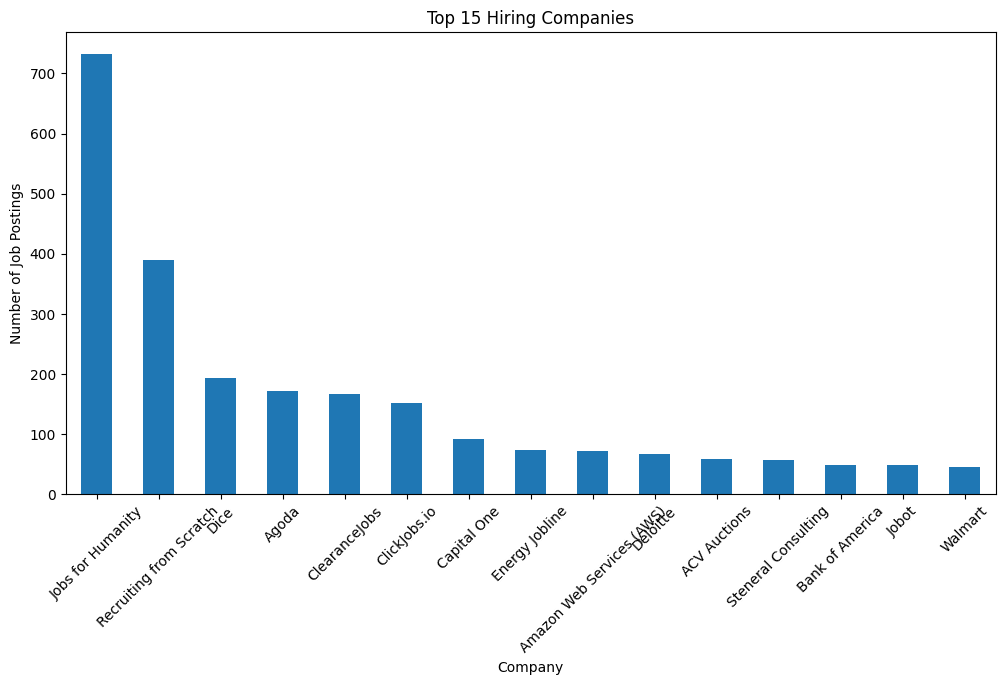

In [32]:
top_companies.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Top 15 Hiring Companies")
plt.xlabel("Company")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45)

plt.show()

# Hiring Location Analysis

This analysis identifies cities with the highest concentration of job opportunities.

Location insights help students understand where the demand for data professionals is strongest.

In [33]:
top_cities = (
    job_postings["search_city"]
    .dropna()
    .value_counts()
    .head(15)
)

top_cities

search_city
Greater London    189
Austin            172
Santa Clara       137
Garland           137
Baytown           117
Chicago           116
Eastchester       113
Summit            109
Bound Brook       106
Montpelier        105
Novato            103
Alexandria         99
Manassas           98
Norristown         91
North Carolina     89
Name: count, dtype: int64

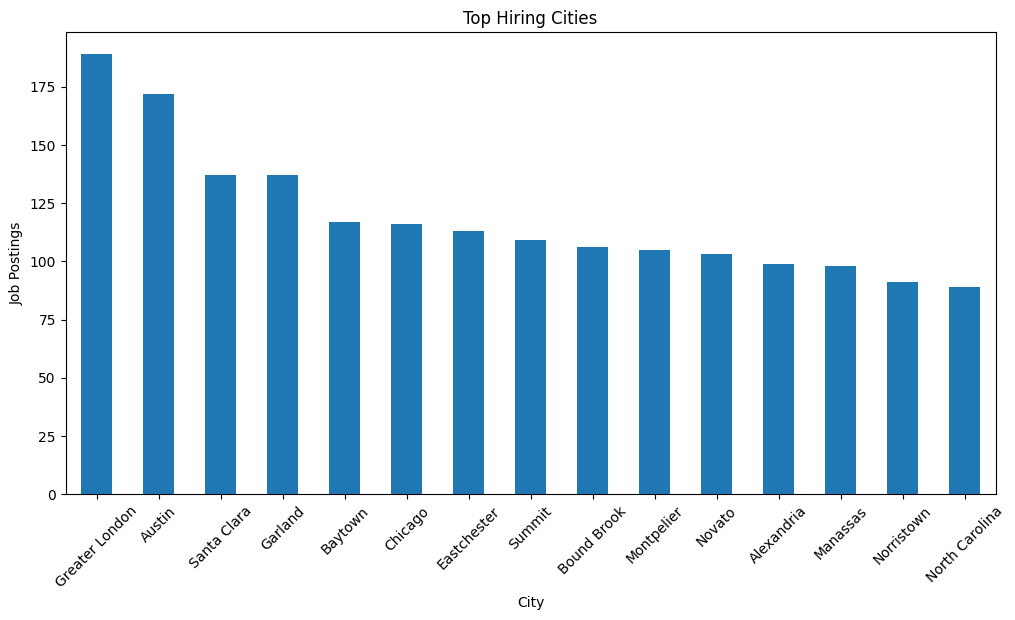

In [34]:
top_cities.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Top Hiring Cities")
plt.xlabel("City")
plt.ylabel("Job Postings")
plt.xticks(rotation=45)

plt.show()

In [35]:
job_postings["job_type"].value_counts()

job_type
Onsite    12188
Remote       18
Hybrid       11
Name: count, dtype: int64

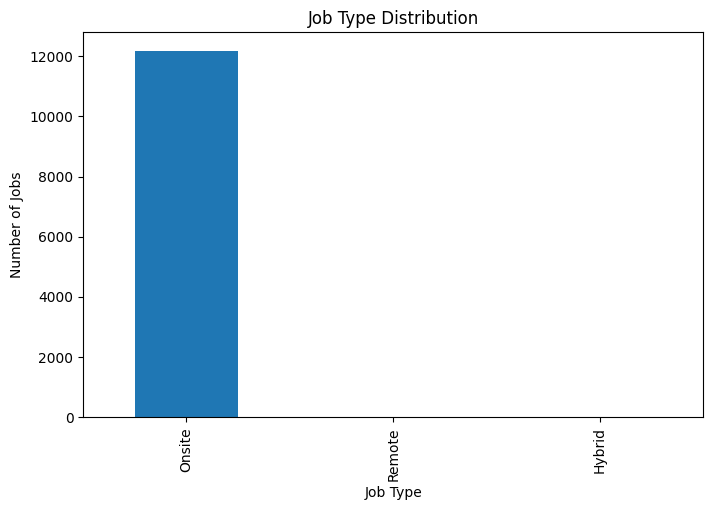

In [37]:
job_type_counts = job_postings["job_type"].value_counts()

job_type_counts.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Job Type Distribution")
plt.xlabel("Job Type")
plt.ylabel("Number of Jobs")

plt.show()

## Key Business Insights

### Hiring Trends
- Identify the companies with the highest recruitment activity.
- Understand geographical demand distribution.
- Analyze dominant employment types.

### Career Implications
Students can prioritize:
- Locations with higher hiring demand.
- Companies with consistent recruitment patterns.
- Skills aligned with the most active employers.

### Strategic Value
These insights help users make informed decisions regarding:
- Job applications
- Skill development
- Relocation opportunities
- Career planning

In [38]:
print("Total Jobs:", len(job_postings))

Total Jobs: 12217


In [39]:
print("Total Companies:", job_postings["company"].nunique())

Total Companies: 3947


In [40]:
print("Total Cities:", job_postings["search_city"].nunique())

Total Cities: 801


In [41]:
job_postings["company"].value_counts().head(10)

company
Jobs for Humanity            732
Recruiting from Scratch      390
Dice                         193
Agoda                        172
ClearanceJobs                166
ClickJobs.io                 152
Capital One                   92
Energy Jobline                73
Amazon Web Services (AWS)     72
Deloitte                      67
Name: count, dtype: int64

In [42]:
job_postings["search_city"].value_counts().head(10)

search_city
Greater London    189
Austin            172
Santa Clara       137
Garland           137
Baytown           117
Chicago           116
Eastchester       113
Summit            109
Bound Brook       106
Montpelier        105
Name: count, dtype: int64

In [43]:
def careercopilot(user_skills, target_role):

    required_skills = career_paths[target_role]["required_skills"]

    matched = [
        skill for skill in required_skills
        if skill in user_skills
    ]

    missing = [
        skill for skill in required_skills
        if skill not in user_skills
    ]

    readiness = (
        len(matched) /
        len(required_skills)
    ) * 100

    print("="*50)
    print("CAREERCOPILOT AI REPORT")
    print("="*50)

    print("\nTarget Role:", target_role)
    print("\nReadiness Score:", round(readiness,2), "%")

    print("\nMissing Skills:")
    for skill in missing:
        print("-", skill)

    return readiness

In [44]:
careercopilot(
    ["Python","Excel"],
    "Data Analyst"
)

CAREERCOPILOT AI REPORT

Target Role: Data Analyst

Readiness Score: 33.33 %

Missing Skills:
- SQL
- Power BI
- Tableau
- Data Visualization


33.33333333333333

In [45]:
careercopilot(
    ["Python","SQL","Excel"],
    "Business Analyst"
)

careercopilot(
    ["Python","Machine Learning"],
    "Data Scientist"
)

CAREERCOPILOT AI REPORT

Target Role: Business Analyst

Readiness Score: 40.0 %

Missing Skills:
- Power BI
- Communication
- Data Analysis
CAREERCOPILOT AI REPORT

Target Role: Data Scientist

Readiness Score: 40.0 %

Missing Skills:
- SQL
- Statistics
- Data Visualization


40.0